Sequence length: 80
{'A': 21, 'T': 25, 'G': 20, 'C': 14}
Sequence length: 80
GC content: 20.175


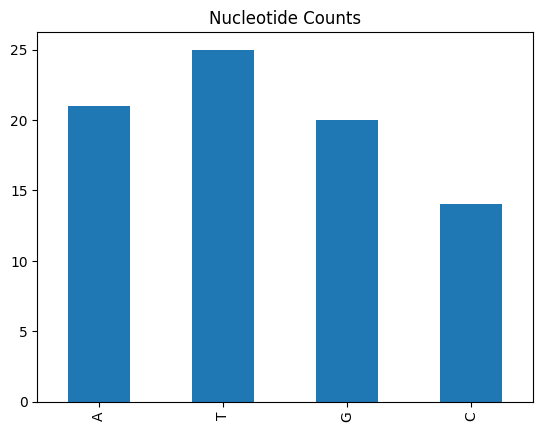

In [1]:
## Single sequence FASTA Analysis

import pandas as pd
from fasta_parser import count_bases_from_fasta

seq,counts = count_bases_from_fasta("test_sequence.fasta")

print("Sequence length:",len(seq))
counts

df = pd.DataFrame.from_dict(counts, orient="index", columns=["count"])
gc = (counts["G"] + counts["C"] / sum(counts.values()))

plot = df.plot(kind="bar", legend=False, title="Nucleotide Counts")
plot
print("GC content:",gc)

,length
TestSequence2,40
TestSequence3,40


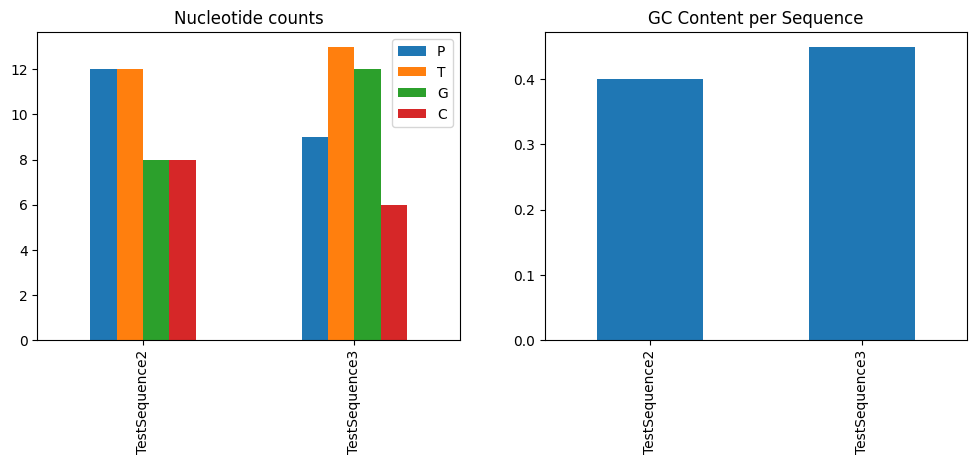

In [ ]:
## Multi FASTA Analysis

import pandas as pd
import matplotlib.pyplot as plt

from multifasta_parser import count_bases_multi,parse_multi_fasta
seqs = parse_multi_fasta("test_sequence.fasta")
results = count_bases_multi(seqs)

df = pd.DataFrame(results).T
dfGC = (df["G"]+df["C"])/df.sum(axis=1)

## Plots

fig, axes = plt.subplots(1,2, figsize=(12,4))
df.plot(kind="bar", ax=axes[0], title=("Nucleotide counts"))
dfGC.plot(kind="bar", ax=axes[1], title=("GC Content per Sequence"))

## Sequence lengths

sequence_lengths = {header:len(seq) for header, seq in seqs.items()}
df1 = pd.DataFrame.from_dict(sequence_lengths, orient="index", columns=["length"])
df1



[np.float64(40.0), np.float64(39.0), np.float64(6.909090909090909)]


Text(0.5, 1.0, 'Per-read mean quality distribution')

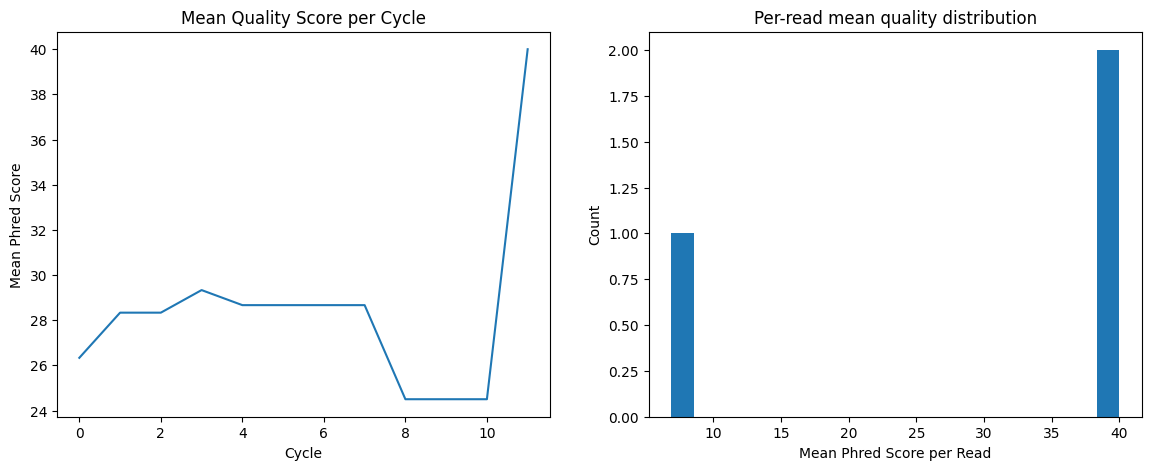

In [ ]:
## FASTQ Parsing & Quality Scores
import numpy as np
import matplotlib.pyplot as plt
from itertools import zip_longest
from fastq_parser import parse_fastq,phred_scores,per_read_mean

file = "test_sequence.fastq"

seqs,quals = parse_fastq(file)
phred_scores(quals[0])

##array synthesis
all_scores = [phred_scores(q) for q in quals]
padded = list(zip_longest(*all_scores, fillvalue=np.nan))
per_cycle = np.array(padded).T
mean_quality = np.nanmean(per_cycle, axis=0)

fig, axes = plt.subplots(1,2,figsize=(14,5))

##plot formation - Mean Quality Score per Cycle 

axes[0].plot(mean_quality)
axes[0].set_title("Mean Quality Score per Cycle")
axes[0].set_xlabel("Cycle")
axes[0].set_ylabel("Mean Phred Score")

PRM = [np.mean(s) for s in all_scores]
print(PRM)

## plot formation - per read mean
axes[1].hist(PRM,bins=20)
axes[1].set_xlabel("Mean Phred Score per Read")
axes[1].set_ylabel("Count")
axes[1].set_title("Per-read mean quality distribution")


[('A', 'T', 'G'), ('C', 'T', 'A'), ('G', 'G', 'T'), ('T', 'A', 'C'), ('A', 'C', 'T'), ('C', 'C', 'A'), ('G', 'G', 'G'), ('T', 'T', 'C'), ('A', 'N', 'T'), ('C', 'N', 'A'), ('G', 'N', 'N'), ('T', 'N', 'N')]
[50.0, 50.0, 40.0]


Text(0, 0.5, 'GC%')

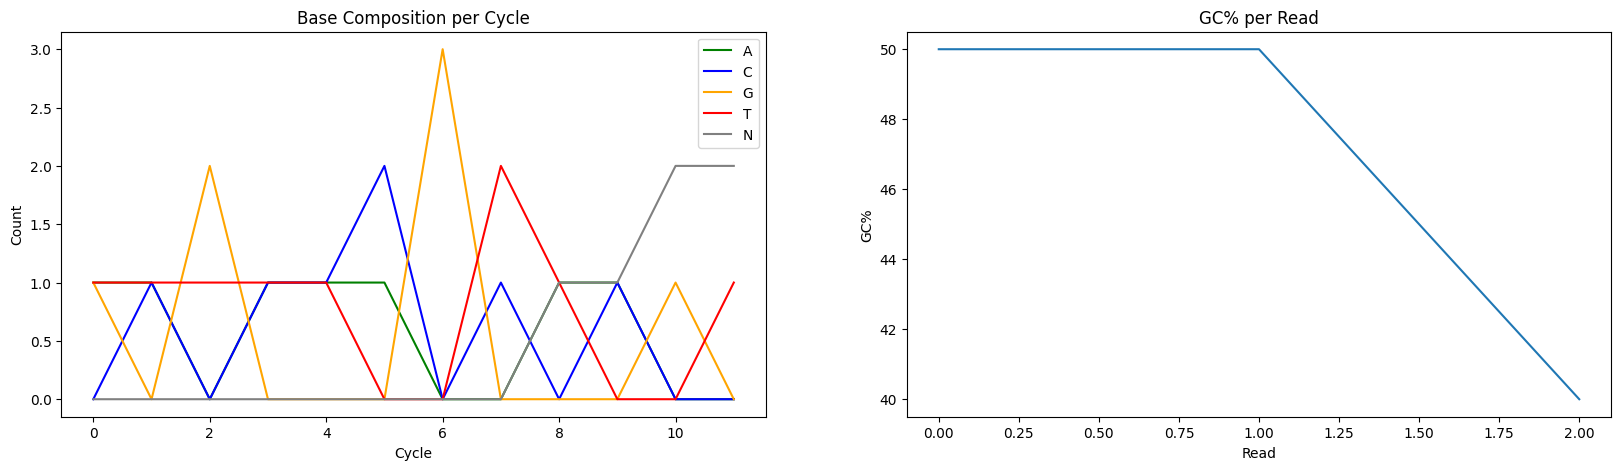

In [3]:
## Base Composition per Cycle

from fastq_parser import base_comp_per_cycle,gc_computation,parse_fastq
import matplotlib.pyplot as plt

file = ("test_sequence.fastq")

## Base composition 

results = base_comp_per_cycle(file)

A = [cycle["A"] for cycle in results]
C = [cycle["C"] for cycle in results]
G = [cycle["G"] for cycle in results]
T = [cycle["T"] for cycle in results]
N = [cycle["N"] for cycle in results]

cycles = range(len(results))

## GC per read

seq,qual = parse_fastq(file)
gcpercentage = gc_computation(seq)
print(gcpercentage)

## Base composition plot 

fig,axes = plt.subplots(1,2, figsize=(20,5))

axes[0].plot(cycles, A, label="A", color="green")
axes[0].plot(cycles, C, label="C", color="blue")
axes[0].plot(cycles, G, label="G", color="orange")
axes[0].plot(cycles, T, label="T", color="red")
axes[0].plot(cycles, N, label="N", color="grey")

axes[0].set_title("Base Composition per Cycle")
axes[0].set_xlabel("Cycle")
axes[0].set_ylabel("Count")
axes[0].legend()

## GC per read plot

axes[1].plot(gcpercentage)
axes[1].set_title("GC% per Read")
axes[1].set_xlabel("Read")
axes[1].set_ylabel("GC%")

